In [67]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importing neccessary libaries

In [22]:
company_names = []
ratings = []
reviews_count = []
salary_count = []
interview_count = []
jobs_count = []
company_sector = []
locations = []
benefits_count = []
page_num = []
# total coloumn used 

In [23]:
base_url = "https://www.ambitionbox.com/list-of-companies?campaign=homepage_companies_widget"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Accept-Language': 'en-US,en;q=0.9'
}

total_time = time.time()
# the website we choosed is AmbitionBox

In [24]:
for i in range(1, 51):   # Webscrapping from the website,getting the neccessary data
    start_time = time.time()
    url = f"{base_url}&page={i}"
    page = requests.get(url, headers=headers)
    s = BeautifulSoup(page.text, "html.parser")

    cards = s.find_all('div', attrs={'class': 'companyCardWrapper'})
    if not cards:
        print(f"No data found on page {i}, stopping...")
        break

    # Company Name
    for x in s.find_all('h2', attrs={'class': 'companyCardWrapper__companyName'}):
        company_names.append(x.text.strip() if x else np.nan)

    # Rating
    for x in s.find_all('div', attrs={'class': 'rating_star_container'}):
        ratings.append(x.text.strip() if x else np.nan)

    # Reviews
    for x in s.find_all('span', attrs={'class': 'companyCardWrapper__ActionTitle'}, string='Reviews'):
        val = x.find_previous_sibling('span')
        reviews_count.append(val.text.strip() if val else np.nan)

    # Salaries
    for x in s.find_all('span', attrs={'class': 'companyCardWrapper__ActionTitle'}, string='Salaries'):
        val = x.find_previous_sibling('span')
        salary_count.append(val.text.strip() if val else np.nan)

    # Interviews
    for x in s.find_all('span', attrs={'class': 'companyCardWrapper__ActionTitle'}, string='Interviews'):
        val = x.find_previous_sibling('span')
        interview_count.append(val.text.strip() if val else np.nan)

    # Jobs
    for x in s.find_all('span', attrs={'class': 'companyCardWrapper__ActionTitle'}, string='Jobs'):
        val = x.find_previous_sibling('span')
        jobs_count.append(val.text.strip() if val else np.nan)

    # Sector and Location
    for x in s.find_all('span', attrs={'class': 'companyCardWrapper__interLinking'}):
        text = x.text.strip()
        parts = text.split('|')
        company_sector.append(parts[0].strip() if len(parts) > 0 else np.nan)
        locations.append(parts[1].strip() if len(parts) > 1 else np.nan)

    # Benefits
    for x in s.find_all('span', attrs={'class': 'companyCardWrapper__ActionTitle'}, string='Benefits'):
        val = x.find_previous_sibling('span')
        benefits_count.append(val.text.strip() if val else np.nan)

    # Page Number
    for _ in range(len(cards)):
        page_num.append(i)

    print(f"Page {i} completed in {time.time() - start_time:.2f} seconds")

print("Total Time Completed in seconds:", str(time.time() - total_time))


Page 1 completed in 2.57 seconds
Page 2 completed in 3.02 seconds
Page 3 completed in 2.62 seconds
Page 4 completed in 2.54 seconds
Page 5 completed in 2.50 seconds
Page 6 completed in 2.69 seconds
Page 7 completed in 2.45 seconds
Page 8 completed in 2.79 seconds
Page 9 completed in 2.60 seconds
Page 10 completed in 2.75 seconds
Page 11 completed in 2.72 seconds
Page 12 completed in 2.52 seconds
Page 13 completed in 2.64 seconds
Page 14 completed in 2.60 seconds
Page 15 completed in 2.38 seconds
Page 16 completed in 2.23 seconds
Page 17 completed in 2.72 seconds
Page 18 completed in 3.55 seconds
Page 19 completed in 2.73 seconds
Page 20 completed in 2.67 seconds
Page 21 completed in 2.71 seconds
Page 22 completed in 2.76 seconds
Page 23 completed in 2.81 seconds
Page 24 completed in 2.71 seconds
Page 25 completed in 2.62 seconds
Page 26 completed in 2.62 seconds
Page 27 completed in 2.65 seconds
Page 28 completed in 2.67 seconds
Page 29 completed in 3.15 seconds
Page 30 completed in 2.

In [25]:
df = pd.DataFrame( {"company_names":company_names,
                    "ratings" : ratings,
                    "reviews_count" : reviews_count,
                    "salary_count" : salary_count,
                    "interview_count" :interview_count,
                    "jobs_count" :jobs_count,
                    "company_sector" : company_sector,
                    "locations":locations,
                    "benefits_count":benefits_count,
                    "page_num":page_num })
# converting the data into DataFrame

In [26]:
df.to_csv('Raw Data.csv', index=False) # converted the dataframe into csv file 

In [27]:
df

,company_names,ratings,reviews_count,salary_count,interview_count,jobs_count,company_sector,locations,benefits_count,page_num
0,TCS,3.3,1.1L,9.9L,11.9k,3k,IT Services & Consulting,Bengaluru +439 other locations,10.6k,1
1,Accenture,3.7,72k,6.5L,9.2k,37.2k,IT Services & Consulting,Bengaluru +255 other locations,6.7k,1
2,Wipro,3.6,63.9k,4.8L,6.7k,5k,IT Services & Consulting,Hyderabad +370 other locations,4.6k,1
3,Cognizant,3.6,60.3k,6L,6.3k,618,IT Services & Consulting,Hyderabad +230 other locations,5.5k,1
4,Capgemini,3.7,51.9k,4.8L,5.5k,2.2k,IT Services & Consulting,Bengaluru +182 other locations,3.7k,1
...,...,...,...,...,...,...,...,...,...,...
995,Bharat Sanchar Nigam,3.9,1k,2.5k,47,--,Telecom,Bengaluru +241 other locations,101,50
996,Dana Anand,4.0,1k,2.9k,52,--,Auto Components,Pune +47 other locations,125,50
997,Tata Capital Housing Finance,3.9,1k,3.2k,49,--,NBFC,Mumbai +168 other locations,4,50
998,GlobalData,3.4,1k,5.7k,92,99,Analytics & KPO,Hyderabad +22 other locations,101,50


In [28]:
df.isnull().sum() # check with missing values

company_names      0
ratings            0
reviews_count      0
salary_count       0
interview_count    0
jobs_count         0
company_sector     0
locations          2
benefits_count     0
page_num           0
dtype: int64

In [29]:
df.dropna() # since we have only 1 missing value in location we use dropna to drop the value

,company_names,ratings,reviews_count,salary_count,interview_count,jobs_count,company_sector,locations,benefits_count,page_num
0,TCS,3.3,1.1L,9.9L,11.9k,3k,IT Services & Consulting,Bengaluru +439 other locations,10.6k,1
1,Accenture,3.7,72k,6.5L,9.2k,37.2k,IT Services & Consulting,Bengaluru +255 other locations,6.7k,1
2,Wipro,3.6,63.9k,4.8L,6.7k,5k,IT Services & Consulting,Hyderabad +370 other locations,4.6k,1
3,Cognizant,3.6,60.3k,6L,6.3k,618,IT Services & Consulting,Hyderabad +230 other locations,5.5k,1
4,Capgemini,3.7,51.9k,4.8L,5.5k,2.2k,IT Services & Consulting,Bengaluru +182 other locations,3.7k,1
...,...,...,...,...,...,...,...,...,...,...
995,Bharat Sanchar Nigam,3.9,1k,2.5k,47,--,Telecom,Bengaluru +241 other locations,101,50
996,Dana Anand,4.0,1k,2.9k,52,--,Auto Components,Pune +47 other locations,125,50
997,Tata Capital Housing Finance,3.9,1k,3.2k,49,--,NBFC,Mumbai +168 other locations,4,50
998,GlobalData,3.4,1k,5.7k,92,99,Analytics & KPO,Hyderabad +22 other locations,101,50


In [30]:
df.duplicated().sum() #checking with duplicated values

np.int64(0)

In [31]:
df.info() # detail info about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company_names    1000 non-null   object
 1   ratings          1000 non-null   object
 2   reviews_count    1000 non-null   object
 3   salary_count     1000 non-null   object
 4   interview_count  1000 non-null   object
 5   jobs_count       1000 non-null   object
 6   company_sector   1000 non-null   object
 7   locations        998 non-null    object
 8   benefits_count   1000 non-null   object
 9   page_num         1000 non-null   int64 
dtypes: int64(1), object(9)
memory usage: 78.3+ KB


In [42]:
df1 = df.to_csv("cleaned_data.csv",index=False) # converted raw data into cleaned data as csv file

In [43]:
df1=pd.read_csv("cleaned_data.csv") #imported the csv file

In [44]:
df1

,company_names,ratings,reviews_count,salary_count,interview_count,jobs_count,company_sector,locations,benefits_count,page_num
0,TCS,3.3,1.1L,9.9L,11.9k,3k,IT Services & Consulting,Bengaluru +439 other locations,10.6k,1
1,Accenture,3.7,72k,6.5L,9.2k,37.2k,IT Services & Consulting,Bengaluru +255 other locations,6.7k,1
2,Wipro,3.6,63.9k,4.8L,6.7k,5k,IT Services & Consulting,Hyderabad +370 other locations,4.6k,1
3,Cognizant,3.6,60.3k,6L,6.3k,618,IT Services & Consulting,Hyderabad +230 other locations,5.5k,1
4,Capgemini,3.7,51.9k,4.8L,5.5k,2.2k,IT Services & Consulting,Bengaluru +182 other locations,3.7k,1
...,...,...,...,...,...,...,...,...,...,...
995,Bharat Sanchar Nigam,3.9,1k,2.5k,47,--,Telecom,Bengaluru +241 other locations,101,50
996,Dana Anand,4.0,1k,2.9k,52,--,Auto Components,Pune +47 other locations,125,50
997,Tata Capital Housing Finance,3.9,1k,3.2k,49,--,NBFC,Mumbai +168 other locations,4,50
998,GlobalData,3.4,1k,5.7k,92,99,Analytics & KPO,Hyderabad +22 other locations,101,50


In [45]:
df1['salary_count'] = df1['salary_count'].apply(lambda x: 
    float(x.replace('L',''))*100000 if 'L' in str(x) 
    else float(x.replace('k',''))*1000 if 'k' in str(x) 
    else 0 if x=='--' 
    else float(x)
)
df1['salary_count'] = df1['salary_count'].apply(lambda x: int(x))
# data manipulation

In [46]:
cols = ['reviews_count','interview_count','jobs_count','benefits_count']

for col in cols:
    df1[col] = (
        df1[col]
        .astype(str)
        .replace('--', '0')
        .str.lower()
        .apply(lambda x: float(x.replace('k',''))*1000 if 'k' in x
               else float(x.replace('l',''))*100000 if 'l' in x
               else float(x))
        .astype(int)
    )

In [47]:
df1['ratings'] = df1['ratings'].astype(float)

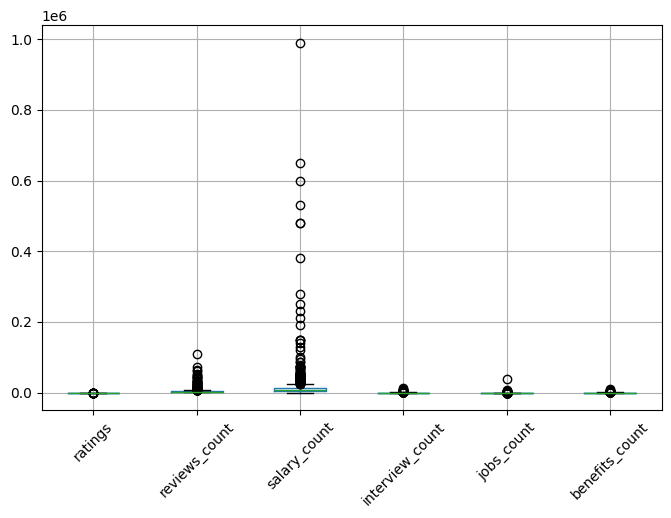

In [49]:
df1[['ratings','reviews_count','salary_count','interview_count','jobs_count','benefits_count']].boxplot(figsize=(8,5))
plt.xticks(rotation=45)
plt.show()
#detecting the data with outliers

In [50]:
numeric_cols = ['ratings','reviews_count','salary_count','interview_count','jobs_count','benefits_count']
for col in numeric_cols :    
    Q1 = df1[col].quantile(0.25)      
    Q3 = df1[col].quantile(0.75)     
    IQR = Q3 - Q1                      # Interquartile range
    
    lower_bound = Q1 - 1.5 * IQR      
    upper_bound = Q3 + 1.5 * IQR       
    
    # Apply capping
    df1[col] = df1[col].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))
# performing IQR Method and capping the outliers 

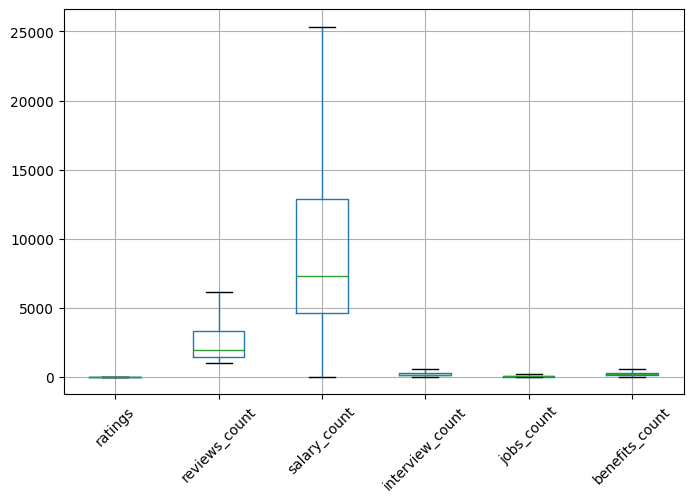

In [51]:
df1[['ratings','reviews_count','salary_count','interview_count','jobs_count','benefits_count']].boxplot(figsize=(8,5))
plt.xticks(rotation=45)
plt.show()
#after capping the outliers

In [53]:
cat_cols = df1.select_dtypes(["object"]).columns.tolist()
cat_cols
# categorical columns in our dataset

['company_names', 'company_sector', 'locations']

In [54]:
numeric_cols = ['ratings','reviews_count','salary_count','interview_count','jobs_count','benefits_count']
numeric_cols
#numerical columns in our dataset

['ratings',
 'reviews_count',
 'salary_count',
 'interview_count',
 'jobs_count',
 'benefits_count']

In [55]:
df['company_names'].unique() # differene company_names used in our dataset

array(['TCS', 'Accenture', 'Wipro', 'Cognizant', 'Capgemini', 'HDFC Bank',
       'Infosys', 'ICICI Bank', 'HCLTech', 'Tech Mahindra', 'Genpact',
       'Teleperformance', 'Jio', 'Axis Bank', 'Concentrix Corporation',
       'Amazon', 'iEnergizer', 'Reliance Retail', 'LTIMindtree', 'IBM',
       'HDB Financial Services', 'Larsen & Toubro Limited', 'Deloitte',
       'Kotak Mahindra Bank', 'Reliance Industries', 'Vodafone Idea',
       'Bharti Airtel', "BYJU'S", 'WNS', 'IDFC FIRST Bank',
       'Ernst & Young', 'Tata Motors', 'IndusInd Bank',
       'AU Small Finance Bank', 'Bajaj Finserv', 'Muthoot FinCorp',
       'Flipkart', 'PwC', 'Mahindra & Mahindra', 'Infosys BPM',
       'DXC Technology', 'HDFC Life', 'Bandhan Bank',
       'Digitide Solutions', 'Mphasis', 'Yes Bank', 'Tata Steel', 'Quess',
       'Maruti Suzuki', 'Asian Paints', 'Startek', 'UltraTech Cement',
       'Paytm', 'Bajaj Finance', 'Shriram Finance',
       'Sutherland Global Services', 'Equitas Small Finance Bank',
 

# Univaraite Analysis (study of one variable at a time that could be categorical or numerical)

In [56]:
numeric_cols = df1.select_dtypes(include=['int64', 'float64'])
# measures of central tendency on numerical data
central_tendency = pd.DataFrame({
    "Mean": numeric_cols.mean(),
    "Median": numeric_cols.median(),
    "Mode": numeric_cols.mode().iloc[0]
})
central_tendency
# We have collected the numerical columns and on that we have applied
# mean, median, mode and converted into a dataframe

,Mean,Median,Mode
ratings,3.813800,3.8,3.900
reviews_count,2587.700000,1900.0,6150.000
salary_count,9877.382000,7300.0,25350.000
interview_count,207.793500,152.0,528.250
jobs_count,47.301125,20.0,0.000
benefits_count,209.419500,161.0,536.625
page_num,25.500000,25.5,1.000


In [57]:
dispersion = pd.DataFrame({
    "Min": numeric_cols.min(),
    "Max": numeric_cols.max(),
    "Range": numeric_cols.max() - numeric_cols.min(),
    "Variance": numeric_cols.var(),
    "Std Dev": numeric_cols.std(),
    "IQR": numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25)
})
dispersion
# We have applied measures of dispersion on the dataframe on the numerical columns

,Min,Max,Range,Variance,Std Dev,IQR
ratings,3.0,4.600,1.600,9.508464e-02,0.308358,0.40
reviews_count,1000.0,6150.000,5150.000,2.600459e+06,1612.593926,1900.00
salary_count,0.0,25350.000,25350.000,5.141034e+07,7170.100644,8300.00
interview_count,1.0,528.250,527.250,2.167062e+04,147.209441,172.50
jobs_count,0.0,168.625,168.625,3.330848e+03,57.713500,66.25
benefits_count,1.0,536.625,535.625,2.320033e+04,152.316550,174.25
page_num,1.0,50.000,49.000,2.084585e+02,14.438091,25.00


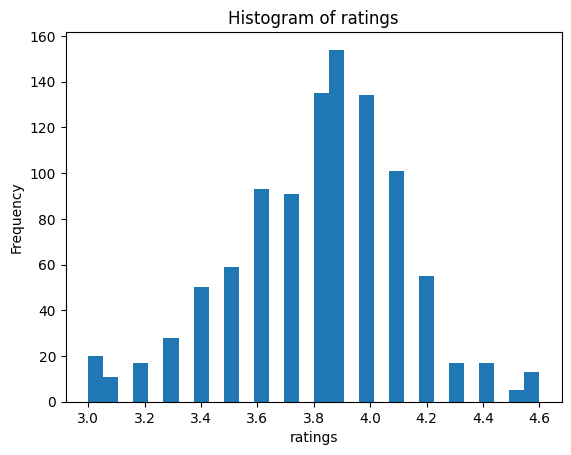

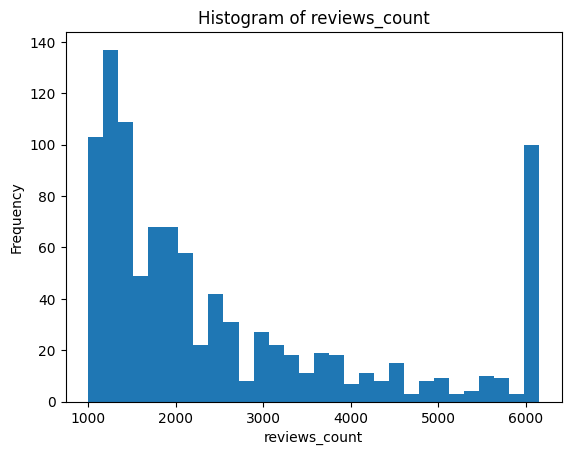

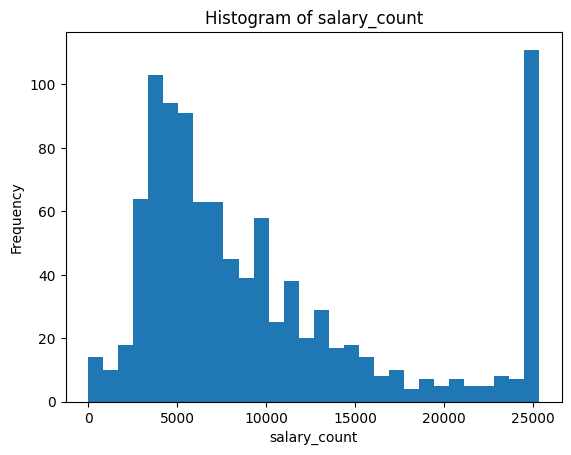

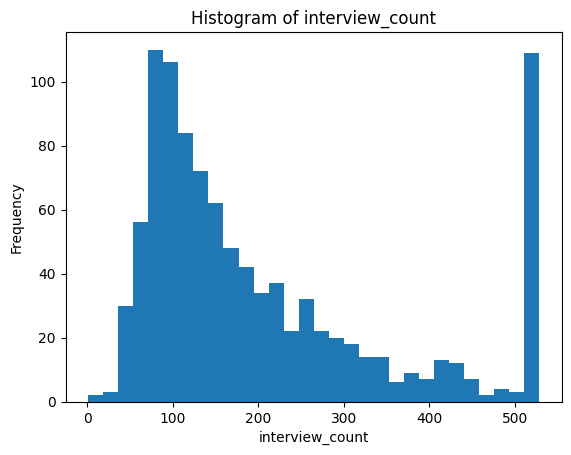

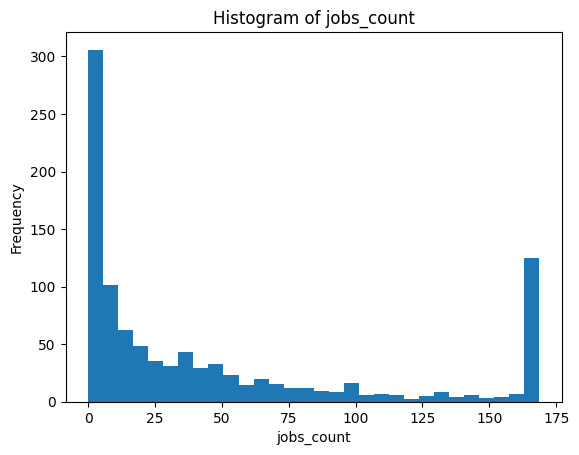

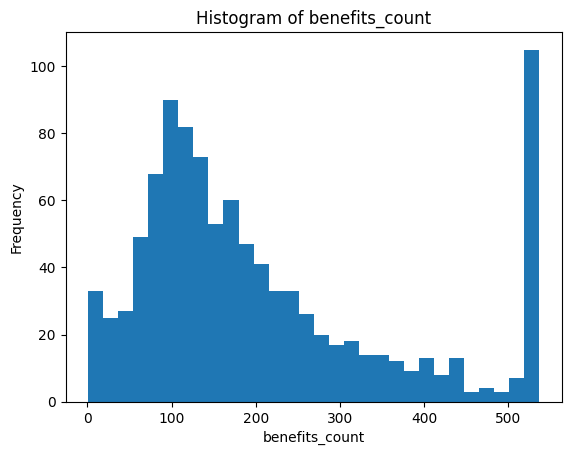

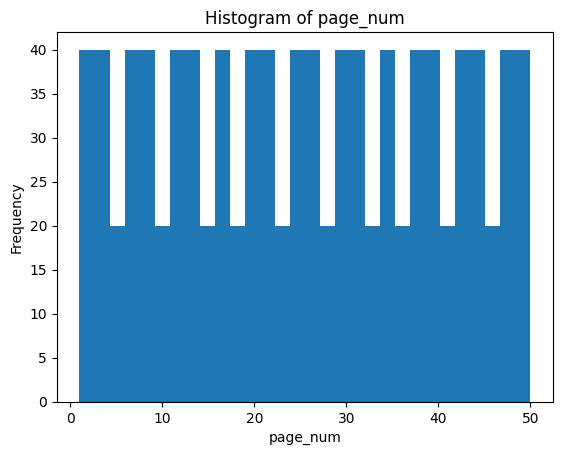

In [58]:
for col in numeric_cols.columns:
    plt.figure()
    plt.hist(numeric_cols[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
"""
Analysis on the histogram graps applied on numerical columns
Reviews_count – Reviews_count is positively skewed, with most values on the lower side and few high values.          
Salary_Ratings – Ratings are mostly concentrated in the higher range, showing a slightly left-skewed distribution.          
count – Salary_count is highly right-skewed, indicating many low values and few very high values.   
Interview_count – Interview_count shows a right-skewed distribution with most observations at lower values.      
Jobs_count – Jobs_count is slightly skewed to the right with majority of data in lower ranges.        
Benefits_count – Benefits_count appears moderately right-skewed with fewer high-value observations.
"""

# Univaraite Analysis on Categorical Variables

In [60]:
cat_col = 'company_names'

freq_table = df1[cat_col].value_counts().reset_index()
freq_table.columns = [cat_col, 'Count']

freq_table['Percentage'] = (freq_table['Count'] / freq_table['Count'].sum()) * 100

print(freq_table)
counts = df1[cat_col].value_counts()
# these are categorical columns in the dataset :['company_names', 'company_sector', 'locations'] 
# performed frequency analysis on a categorical column (company_names) by calculating 
# the count and percentage distribution of each unique category.

                               company_names  Count  Percentage
0                    Sammaan Capital Limited      2         0.2
1                                   Jindal X      2         0.2
2                    Larsen & Toubro Limited      1         0.1
3                         Northcorp Software      1         0.1
4    Bajaj Capital Insurance Broking Limited      1         0.1
..                                       ...    ...         ...
993                     Bharat Sanchar Nigam      1         0.1
994                               Dana Anand      1         0.1
995             Tata Capital Housing Finance      1         0.1
996                               GlobalData      1         0.1
997                                HDFC Bank      1         0.1

[998 rows x 3 columns]


In [61]:
cat_col = 'locations' 

freq_table = df1[cat_col].value_counts().reset_index()
freq_table.columns = [cat_col, 'Count']

freq_table['Percentage'] = (freq_table['Count'] / freq_table['Count'].sum()) * 100

print(freq_table)
counts = df1[cat_col].value_counts()
# performed frequency analysis on a categorical column (locations) by calculating 
# the count and percentage distribution of each unique category.

                          locations  Count  Percentage
0     Bengaluru +21 other locations      7    0.701403
1     Bengaluru +27 other locations      6    0.601202
2     Bengaluru +18 other locations      6    0.601202
3     Bengaluru +36 other locations      5    0.501002
4     Bengaluru +22 other locations      5    0.501002
..                              ...    ...         ...
816     Kolkata +63 other locations      1    0.100200
817     Mumbai +188 other locations      1    0.100200
818  Bengaluru +113 other locations      1    0.100200
819     Mumbai +168 other locations      1    0.100200
820  Hyderabad +230 other locations      1    0.100200

[821 rows x 3 columns]


In [62]:
cat_col = 'company_sector'

freq_table = df1[cat_col].value_counts().reset_index()
freq_table.columns = [cat_col, 'Count']

freq_table['Percentage'] = (freq_table['Count'] / freq_table['Count'].sum()) * 100

print(freq_table)
counts = df1[cat_col].value_counts()
# print(counts)
# performed frequency analysis on a categorical column (company_sector) by calculating 
# the count and percentage distribution of each unique category.

                   company_sector  Count  Percentage
0        IT Services & Consulting    121        12.1
1                 Auto Components     55         5.5
2                            NBFC     53         5.3
3                          Pharma     48         4.8
4              Financial Services     42         4.2
..                            ...    ...         ...
65  Bengaluru +31 other locations      1         0.1
66            Content Development      1         0.1
67         Beauty & Personal Care      1         0.1
68          Accounting & Auditing      1         0.1
69               Waste Management      1         0.1

[70 rows x 3 columns]


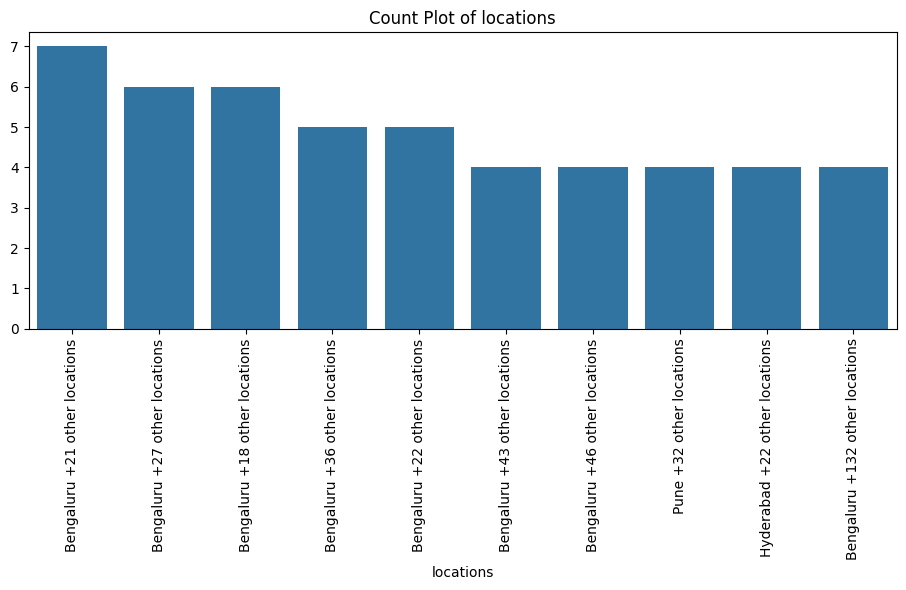

In [83]:
plt.figure(figsize=(18,6))
# top 10 Locations
plt.subplot(1,2,1)
top_locations = df['locations'].value_counts().head(10)
sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)
plt.title("Count Plot of locations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

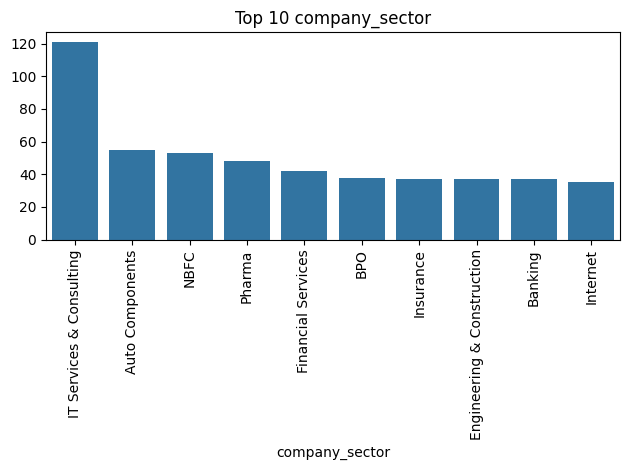

In [84]:
# top 10 Company Sector
top_sector = df['company_sector'].value_counts().head(10)
sns.barplot(
    x=top_sector.index,
    y=top_sector.values
)
plt.title("Top 10 company_sector")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Bi-variate Analysis/Multivariate (study of two variable at the same time or more than two)
## this has 3 combinations
### 1.Numerical VS Categorical 
### 2.Numerical VS Numerical
### 3.Categorical VS Categorical

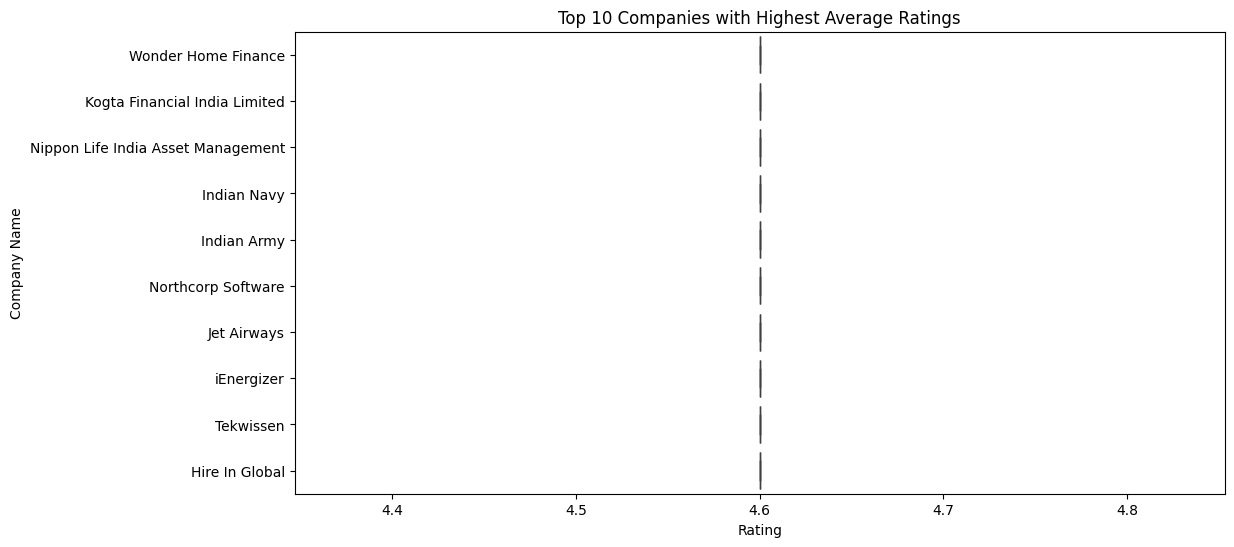

In [85]:
# numerical vs categorical
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df1[df1['company_names'].isin(
        df1.groupby('company_names')['ratings']
          .mean()
          .sort_values(ascending=False)
          .head(10)
          .index
    )],
    x='ratings',
    y='company_names',
    order=df1.groupby('company_names')['ratings']
            .mean()
            .sort_values(ascending=False)
            .head(10)
            .index
)
plt.title("Top 10 Companies with Highest Average Ratings")
plt.xlabel("Rating")
plt.ylabel("Company Name")
plt.show()
# Calculates average rating per company and display top 10 company
# all the top 10 comapny have the same rating of 4.6

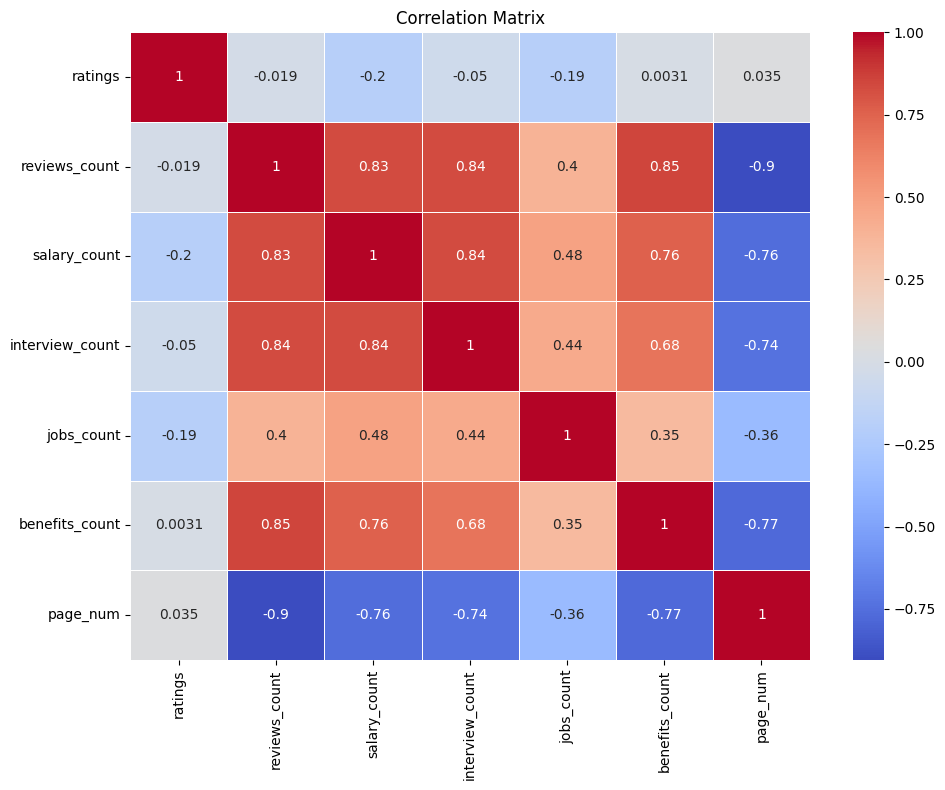

In [87]:
# Numerical VS numerical
corr_matrix = numeric_cols.corr()
# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2g",       
    cmap="coolwarm",    
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# relationship all the numerical variables

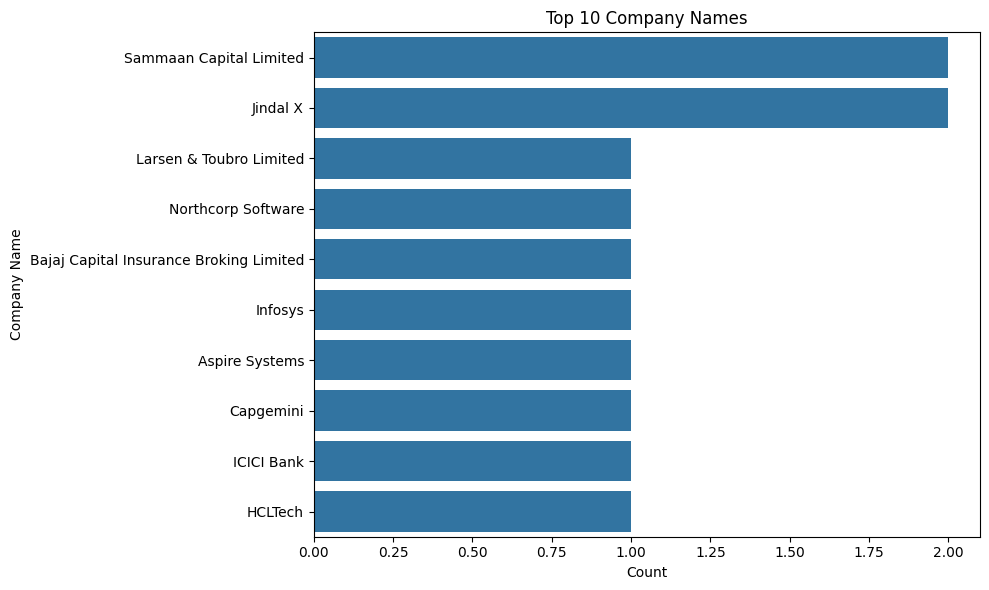

In [89]:
# Categorical VS Categorical
top_companies = df['company_names'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)
plt.title("Top 10 Company Names")
plt.xlabel("Count")
plt.ylabel("Company Name")
plt.tight_layout()
plt.show()


In [ ]:
# disclaimer : The dataset and graphs could change from time to time since we extracting the data from Ambition Box website in realtime the data 
#               could change time to time